# JET Sensitivity Analysis with ECOv002 Cal-Val

This notebook performs a sensitivity analysis of the JET ensemble using ECOSTRESS Collection 2 Cal-Val data. It loads input data, processes it through the JET ensemble, and visualizes the impact of input perturbations on latent heat flux. The notebook also generates figures for publication and explores the relationship between surface temperature and latent heat flux.

## Import Required Libraries and Functions

This cell imports all necessary libraries and functions for data processing, model execution, statistical analysis, and plotting. It includes custom modules for the BESS-JPL model, sensitivity analysis, and net radiation calculations, as well as standard scientific Python libraries.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))
from typing import Callable
from os import makedirs
from os.path import join
import numpy as np
import pandas as pd
from verma_net_radiation import verma_net_radiation_table
from JET3 import process_JET_table, load_ECOv002_calval_JET_inputs
from monte_carlo_sensitivity import perturbed_run, sensitivity_analysis, divide_absolute_by_unperturbed, sensitivity_magnitude_barchart
import matplotlib.pyplot as plt
from scipy.stats import mstats
import seaborn as sns
from matplotlib.ticker import FuncFormatter

## Configuration Options

Set configuration options for the notebook, including whether to save plots to files.

In [2]:
# Configuration: Set to True to save plots to files, False to only display them
SAVE_PLOTS = False

In [3]:
input_variables = [
    "ST_C",
    "NDVI",
    "albedo",
    "Ta_C",
    "RH",
    "AOT",
    "COT",
    "vapor_gccm",
    "ozone_cm",
    "elevation_m",
    "canopy_height_meters"
]

output_variables = [
    "Rn_Wm2",
    "ET_daylight_kg",
    "GPP_inst_g_m2_s"
]

# Per-variable physical bounds to keep perturbations realistic
input_min = {
    "ST_C": 0.0,
    "NDVI": 0.05,
    "albedo": 0.0,
    "Ta_C": 0.0,
    "RH": 0.0,
    "AOT": 0.0,
    "COT": 0.0,
    "vapor_gccm": 0.0,
    "ozone_cm": 0.0,
    "elevation_m": 0.0,
    "canopy_height_meters": 0.0,
}

input_max = {
    "ST_C": 50.0,
    "NDVI": 1,
    "albedo": 1,
}

## Define Processing Function for Model Table

This cell defines the forward process for analysis as the BESS-JPL model.

In [4]:
forward_process = process_JET_table
model_name = "JET"

## Set Normalization Function

This cell assigns the normalization function used to compare perturbed model outputs to the unperturbed baseline. The function `divide_absolute_by_unperturbed` is used for normalization in the sensitivity analysis.

In [5]:
normalization_function = divide_absolute_by_unperturbed

## Load and Filter Input Data

This cell loads the ECOSTRESS Cal-Val input data using a custom loader function and filters out surface temperatures greater than 50 Celsius and NDVI values less than 0.05. The resulting DataFrame is displayed for inspection.

In [6]:
input_df = load_ECOv002_calval_JET_inputs()

# Apply lower and upper bounds from configuration dictionaries
mask = pd.Series(True, index=input_df.index)
for var, min_val in input_min.items():
    if var in input_df.columns:
        mask &= input_df[var] >= min_val
for var, max_val in input_max.items():
    if var in input_df.columns:
        mask &= input_df[var] <= max_val

input_df = input_df[mask]
input_df = input_df.dropna()
input_df

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,CL,Tmin_open,Tmin_closed,VPD_open,VPD_closed,Tmin_C,Topt_C,fAPARmax,field_capacity,wilting_point
15,15,US-xAB,ENF,Csb,141.635670,168.24043,402.81810,159.71700,139.016083,107.183200,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
17,17,US-xAB,ENF,Csb,1.881266,163.94730,301.40400,179.13661,131.273636,106.525215,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
18,18,US-xAB,ENF,Csb,3.135606,246.87700,614.51480,405.50497,366.056641,222.890230,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
19,19,US-xAB,ENF,Csb,311.482820,290.73126,672.27510,478.82382,439.821228,153.787670,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
20,20,US-xAB,ENF,Csb,51.920338,95.28810,116.67136,73.20884,232.693512,24.038680,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,992,US-xML,DBF,Dfb,417.831120,706.93066,523.92740,310.69684,356.174072,148.624050,...,0.0065,11.39,-8.0,650.0,3500.0,27.538052,2.66,0.5404,0.34,0.14
994,994,US-xML,DBF,Dfb,161.558200,306.15277,420.44678,206.48576,237.659103,98.727560,...,0.0065,11.39,-8.0,650.0,3500.0,27.538052,2.66,0.5404,0.34,0.14
1001,1001,US-UiB,CRO,Dfa,93.876100,251.38747,238.71077,198.90399,106.316444,67.694800,...,0.0070,12.02,-8.0,650.0,4500.0,9.637029,2.58,0.4060,0.32,0.14
1020,1020,US-ARM,CRO,Cfa,80.255005,0.00000,180.10085,211.28325,164.581390,84.672410,...,0.0070,12.02,-8.0,650.0,4500.0,9.637029,8.48,0.4017,0.29,0.12


## Process Input Data Through Model

This cell applies the processing function to the filtered input data, running it through the model, and displays the resulting DataFrame.

In [7]:
processed = forward_process(input_df)
processed

[2026-08-06 13:00:50 INFO] starting JET table processing
[2026-08-06 13:00:50 INFO] started extracting geometry from JET input table
[2026-08-06 13:00:50 INFO] completed extracting geometry from JET input table (0.003 seconds)
[2026-08-06 13:00:50 INFO] started extracting time from JET input table
[2026-08-06 13:00:50 INFO] completed extracting time from JET input table (0.001 seconds)
[2026-08-06 13:00:50 INFO] running Forest Light Environmental Simulator
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
[2026-08-06 13:00:50 INFO] completed processing FLiES-ANN in 0.21 seconds
[2026-08-06 13:00:50 INFO] variable PAR_albedo min: 0.007 mean: 0.055 max: 0.193 nan: 0.00% (nan)
[2026-08-06 13:00:50 INFO] variable NIR_albedo min: 0.066 mean: 0.162 max: 0.530 nan: 0.00% (nan)
[2026-08-06 13:00:50 INFO] variable PAR_direct_Wm2 min: 7.148 mean: 269.735 max: 442.463 nan: 0.00% (nan)
[2026-08-06 13:00:50 INFO] variable SWin_FLiES_ANN min: 163.676 mean: 716.916 max: 1095.605 nan: 0.00% (nan)
[2026-08-06 13:00

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-p

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,G_PMJPL_Wm2,G_Wm2,LE_instantaneous_Wm2,LE_Wm2,H_Wm2,ET_daylight_kg,ET_uncertainty,GPP_inst_g_m2_s,ET_canopy_inst_kg_m2_s,WUE
15,15,US-xAB,ENF,Csb,141.635670,168.24043,402.81810,159.71700,139.016083,107.183200,...,24.219544,24.219544,203.764376,203.764376,248.713696,2.900053,0.510811,0.000151,0.000058,2.606544
17,17,US-xAB,ENF,Csb,1.881266,163.94730,301.40400,179.13661,131.273636,106.525215,...,13.772918,13.772918,163.144742,163.144742,194.438550,2.854526,1.085331,0.000108,0.000034,3.174119
18,18,US-xAB,ENF,Csb,3.135606,246.87700,614.51480,405.50497,366.056641,222.890230,...,33.327171,33.327171,342.565013,342.565013,348.501129,4.442026,0.971980,0.000291,0.000122,2.390822
19,19,US-xAB,ENF,Csb,311.482820,290.73126,672.27510,478.82382,439.821228,153.787670,...,42.878466,42.878466,403.011097,403.011097,366.186555,4.947329,1.401781,0.000294,0.000211,1.388074
20,20,US-xAB,ENF,Csb,51.920338,95.28810,116.67136,73.20884,232.693512,24.038680,...,2.903705,2.903705,112.556235,112.556235,52.720986,2.991218,0.730132,0.000095,0.000015,6.238326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,992,US-xML,DBF,Dfb,417.831120,706.93066,523.92740,310.69684,356.174072,148.624050,...,29.623891,29.623891,397.732265,397.732265,216.894638,3.642505,1.045928,0.000233,0.000137,1.697664
994,994,US-xML,DBF,Dfb,161.558200,306.15277,420.44678,206.48576,237.659103,98.727560,...,21.577865,21.577865,285.469147,285.469147,216.864039,2.883329,1.141584,0.000138,0.000101,1.357232
1001,1001,US-UiB,CRO,Dfa,93.876100,251.38747,238.71077,198.90399,106.316444,67.694800,...,77.061858,77.061858,105.892160,105.892160,409.322436,1.323772,1.130343,0.000053,0.000016,3.203371
1020,1020,US-ARM,CRO,Cfa,80.255005,0.00000,180.10085,211.28325,164.581390,84.672410,...,69.968594,69.968594,119.836612,119.836612,285.958690,1.413853,1.294936,0.000048,0.000031,1.555148


## Accuracy Comparison of In-Situ Observations to Model Estimates

Examining the accuracy of model estimates compared to ground data.

analyzing JET accuracy for ET_daylight_kg compared to insitu_ET_daylight_kg


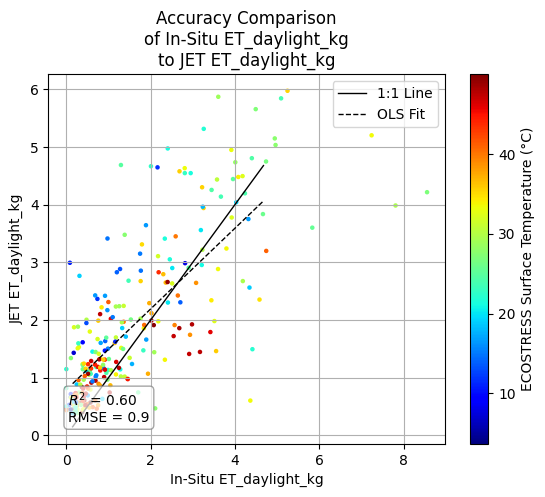

analyzing JET accuracy for G_Wm2 compared to insitu_G_Wm2


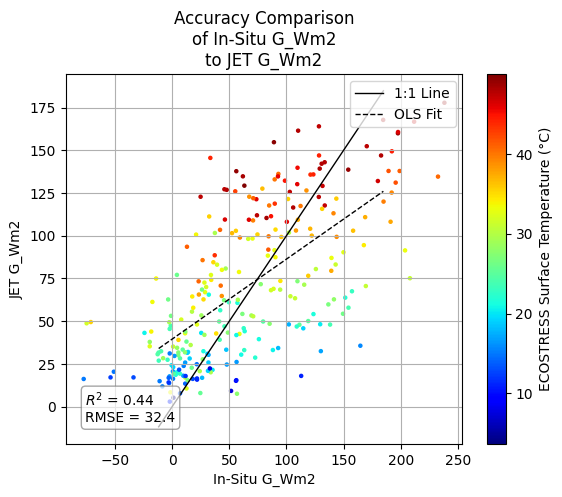

analyzing JET accuracy for H_Wm2 compared to insitu_H_Wm2


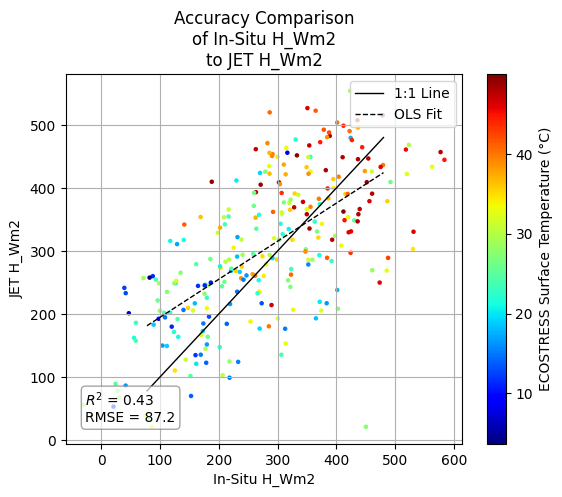

analyzing JET accuracy for LE_Wm2 compared to insitu_LE_Wm2


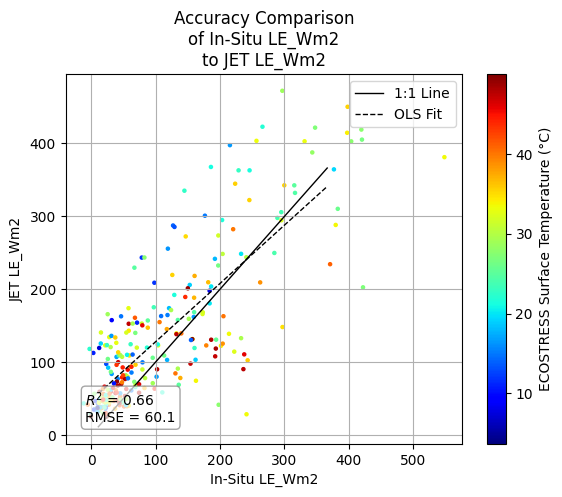

analyzing JET accuracy for LE_daylight_Wm2 compared to insitu_LE_daylight_Wm2
Error processing LE_daylight_Wm2: "['LE_daylight_Wm2'] not in index"
analyzing JET accuracy for RH compared to insitu_RH


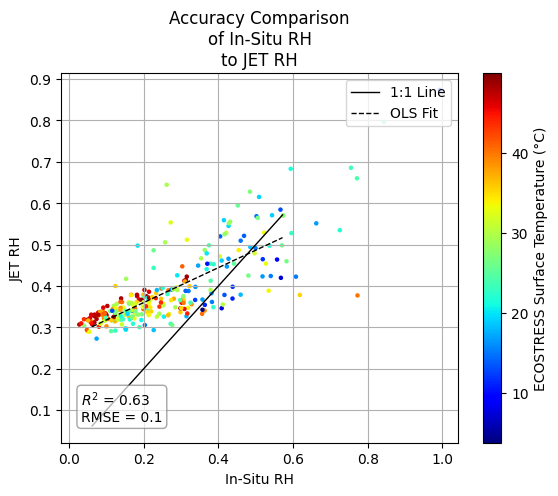

analyzing JET accuracy for Rn_Wm2 compared to insitu_Rn_Wm2


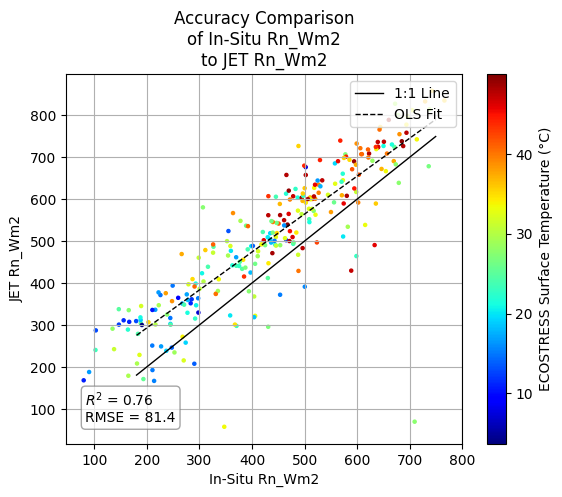

analyzing JET accuracy for Rn_daylight_Wm2 compared to insitu_Rn_daylight_Wm2
Error processing Rn_daylight_Wm2: "['Rn_daylight_Wm2'] not in index"
analyzing JET accuracy for SWin_Wm2 compared to insitu_SWin_Wm2


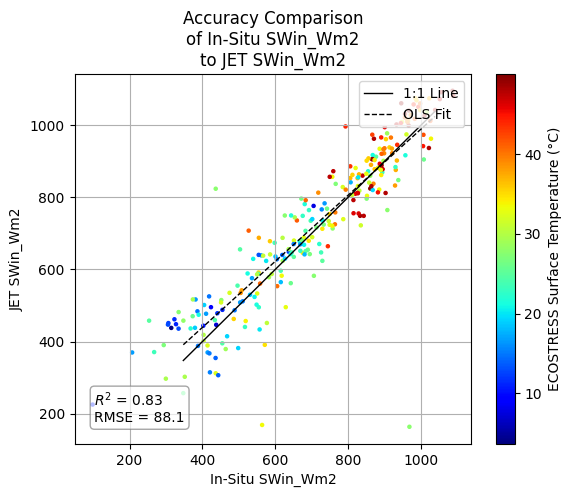

analyzing JET accuracy for Ta_C compared to insitu_Ta_C


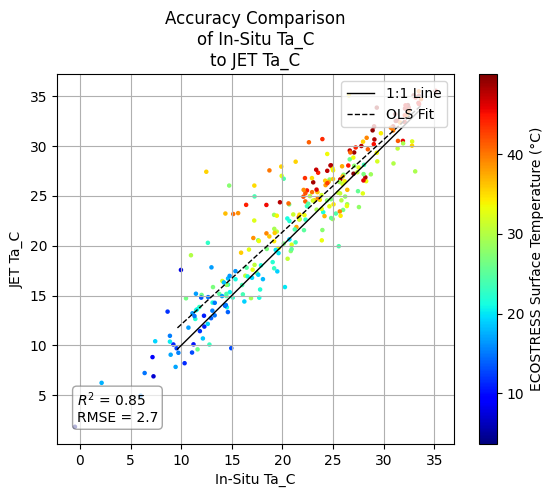

In [8]:
insitu_columns = sorted([column for column in processed.columns if "insitu" in column])

for insitu_variable in insitu_columns:
    try:
        output_variable = insitu_variable.replace("insitu_", "")
        print(f"analyzing {model_name} accuracy for {output_variable} compared to {insitu_variable}")
        
        x_variable = insitu_variable
        y_variable = output_variable

        # Filter out rows with NaN values in either variable
        valid_data = processed[[x_variable, y_variable, 'ST_C']].dropna()
        
        sc = plt.scatter(
            x=valid_data[x_variable],
            y=valid_data[y_variable],
            c=valid_data.ST_C,
            cmap="jet",
            color=None,
            s=5
        )

        # Calculate 5% and 95% tails for x and y variables
        x_5th, x_95th = np.percentile(valid_data[x_variable], [5, 95])
        y_5th, y_95th = np.percentile(valid_data[y_variable], [5, 95])

        min_val = min(x_5th, y_5th)
        max_val = max(x_95th, y_95th)

        # Add 1-to-1 line
        # min_val = min(valid_data[x_variable].min(), valid_data[y_variable].min())
        # max_val = max(valid_data[x_variable].max(), valid_data[y_variable].max())
        plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', linewidth=1, label='1:1 Line')

        # Add OLS regression line
        coefs = np.polyfit(valid_data[x_variable], valid_data[y_variable], 1)
        ols_x = np.array([min_val, max_val])
        ols_y = coefs[0] * ols_x + coefs[1]
        plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

        # Calculate R-squared and RMSE
        from sklearn.metrics import r2_score, mean_squared_error
        y_true = valid_data[y_variable]
        y_pred = coefs[0] * valid_data[x_variable] + coefs[1]
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        # Annotate R-squared and RMSE on plot in lower left corner
        plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
                    xy=(0.05, 0.05), xycoords='axes fraction',
                    ha='left', va='bottom',
                    fontsize=10,
                    bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

        # Set ticks every 100 for both axes
        # xticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
        # yticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
        # plt.xticks(xticks)
        # plt.yticks(yticks)

        plt.grid(True, zorder=0) 
        plt.xlabel(f"In-Situ {output_variable}")
        plt.ylabel(f"{model_name} {output_variable}")
        plt.title(f"Accuracy Comparison\nof In-Situ {output_variable}\nto {model_name} {output_variable}")
        plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
        plt.legend(loc='upper right')
        
        if SAVE_PLOTS:
            plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.jpeg", format='jpeg', bbox_inches='tight')
            plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.svg", format='svg', bbox_inches='tight')
        
        plt.show()
    except Exception as e:
        print(f"Error processing {output_variable}: {e}")
        continue

# Accuracy Comparison for Net Radiation between BESS and Verma

analyzing JET accuracy for Rn_BESS_Wm2 compared to insitu_Rn_Wm2


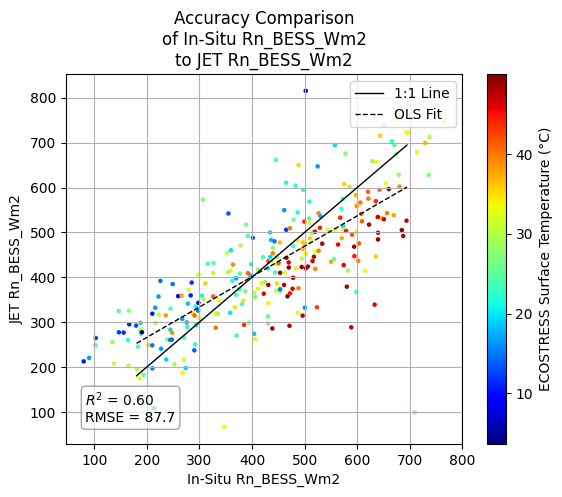

analyzing JET accuracy for Rn_verma_Wm2 compared to insitu_Rn_Wm2


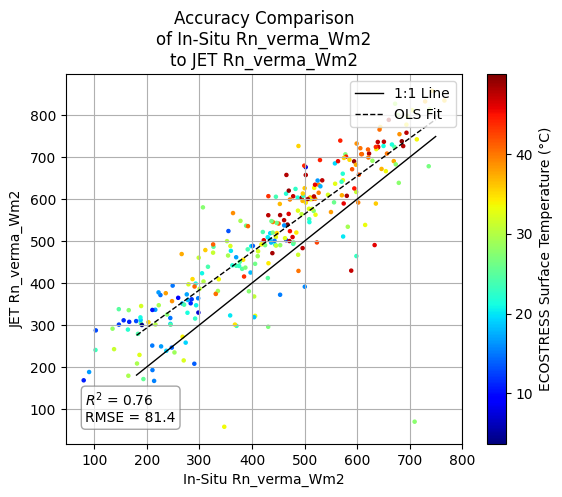

In [9]:
insitu_variable = "insitu_Rn_Wm2"

for output_variable in ["Rn_BESS_Wm2", "Rn_verma_Wm2"]:
    try:
        print(f"analyzing {model_name} accuracy for {output_variable} compared to {insitu_variable}")
        
        x_variable = insitu_variable
        y_variable = output_variable

        # Filter out rows with NaN values in either variable
        valid_data = processed[[x_variable, y_variable, 'ST_C']].dropna()
        
        sc = plt.scatter(
            x=valid_data[x_variable],
            y=valid_data[y_variable],
            c=valid_data.ST_C,
            cmap="jet",
            color=None,
            s=5
        )

        # Calculate 5% and 95% tails for x and y variables
        x_5th, x_95th = np.percentile(valid_data[x_variable], [5, 95])
        y_5th, y_95th = np.percentile(valid_data[y_variable], [5, 95])

        min_val = min(x_5th, y_5th)
        max_val = max(x_95th, y_95th)

        # Add 1-to-1 line
        # min_val = min(valid_data[x_variable].min(), valid_data[y_variable].min())
        # max_val = max(valid_data[x_variable].max(), valid_data[y_variable].max())
        plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', linewidth=1, label='1:1 Line')

        # Add OLS regression line
        coefs = np.polyfit(valid_data[x_variable], valid_data[y_variable], 1)
        ols_x = np.array([min_val, max_val])
        ols_y = coefs[0] * ols_x + coefs[1]
        plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

        # Calculate R-squared and RMSE
        from sklearn.metrics import r2_score, mean_squared_error
        y_true = valid_data[y_variable]
        y_pred = coefs[0] * valid_data[x_variable] + coefs[1]
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        # Annotate R-squared and RMSE on plot in lower left corner
        plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
                    xy=(0.05, 0.05), xycoords='axes fraction',
                    ha='left', va='bottom',
                    fontsize=10,
                    bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

        # Set ticks every 100 for both axes
        # xticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
        # yticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
        # plt.xticks(xticks)
        # plt.yticks(yticks)

        plt.grid(True, zorder=0) 
        plt.xlabel(f"In-Situ {output_variable}")
        plt.ylabel(f"{model_name} {output_variable}")
        plt.title(f"Accuracy Comparison\nof In-Situ {output_variable}\nto {model_name} {output_variable}")
        plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
        plt.legend(loc='upper right')
        
        if SAVE_PLOTS:
            plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.jpeg", format='jpeg', bbox_inches='tight')
            plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.svg", format='svg', bbox_inches='tight')
        
        plt.show()
    except Exception as e:
        print(f"Error processing {output_variable}: {e}")
        continue

analyzing JET accuracy for LE_BESS_Wm2 compared to insitu_LE_Wm2


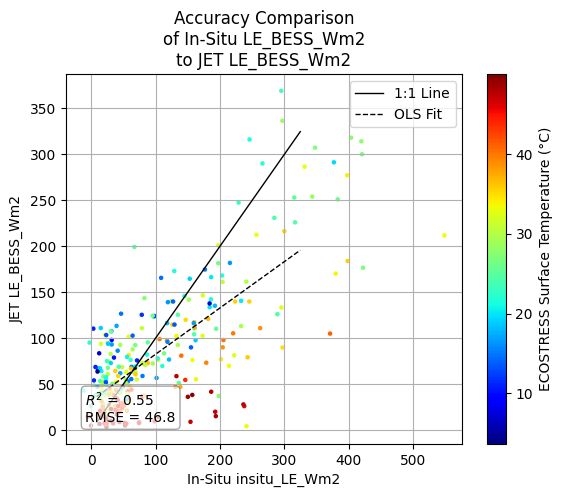

analyzing JET accuracy for LE_STIC_Wm2 compared to insitu_LE_Wm2


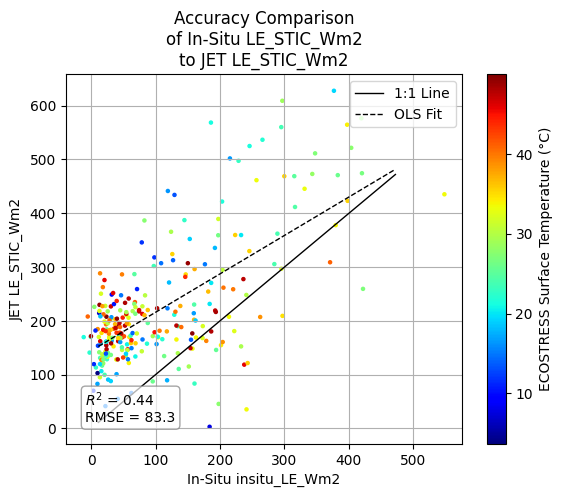

analyzing JET accuracy for LE_PTJPLSM_Wm2 compared to insitu_LE_Wm2


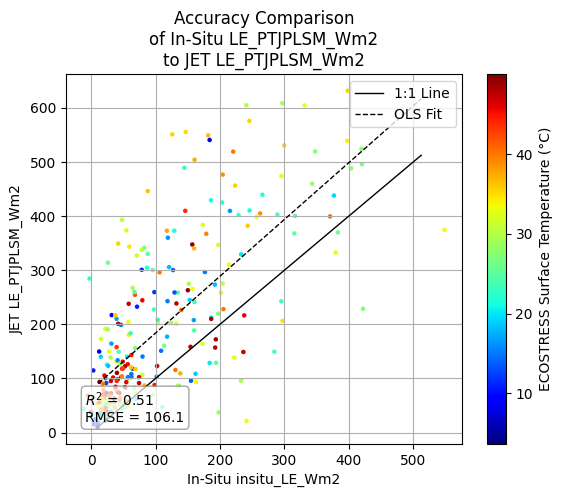

analyzing JET accuracy for LE_PMJPL_Wm2 compared to insitu_LE_Wm2


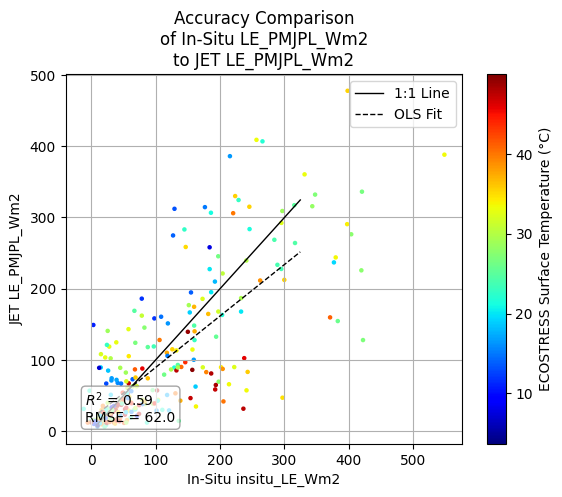

analyzing JET accuracy for LE_Wm2 compared to insitu_LE_Wm2


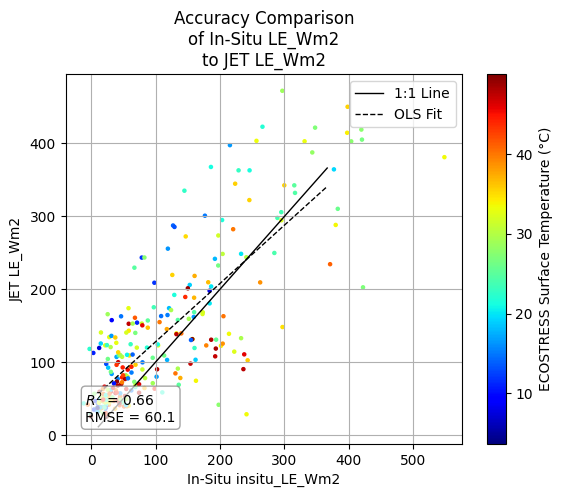

In [10]:
insitu_variable = "insitu_LE_Wm2"

output_variables = [
    "LE_BESS_Wm2",
    "LE_STIC_Wm2",
    "LE_PTJPLSM_Wm2",
    "LE_PMJPL_Wm2",
    "LE_Wm2"
]

for output_variable in output_variables:
    try:
        print(f"analyzing {model_name} accuracy for {output_variable} compared to {insitu_variable}")
        
        x_variable = insitu_variable
        y_variable = output_variable

        # Filter out rows with NaN values in either variable
        valid_data = processed[[x_variable, y_variable, 'ST_C']].dropna()
        
        sc = plt.scatter(
            x=valid_data[x_variable],
            y=valid_data[y_variable],
            c=valid_data.ST_C,
            cmap="jet",
            color=None,
            s=5
        )

        # Calculate 5% and 95% tails for x and y variables
        x_5th, x_95th = np.percentile(valid_data[x_variable], [5, 95])
        y_5th, y_95th = np.percentile(valid_data[y_variable], [5, 95])

        min_val = min(x_5th, y_5th)
        max_val = max(x_95th, y_95th)

        # Add 1-to-1 line
        # min_val = min(valid_data[x_variable].min(), valid_data[y_variable].min())
        # max_val = max(valid_data[x_variable].max(), valid_data[y_variable].max())
        plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', linewidth=1, label='1:1 Line')

        # Add OLS regression line
        coefs = np.polyfit(valid_data[x_variable], valid_data[y_variable], 1)
        ols_x = np.array([min_val, max_val])
        ols_y = coefs[0] * ols_x + coefs[1]
        plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

        # Calculate R-squared and RMSE
        from sklearn.metrics import r2_score, mean_squared_error
        y_true = valid_data[y_variable]
        y_pred = coefs[0] * valid_data[x_variable] + coefs[1]
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        # Annotate R-squared and RMSE on plot in lower left corner
        plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
                    xy=(0.05, 0.05), xycoords='axes fraction',
                    ha='left', va='bottom',
                    fontsize=10,
                    bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

        # Set ticks every 100 for both axes
        # xticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
        # yticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
        # plt.xticks(xticks)
        # plt.yticks(yticks)

        plt.grid(True, zorder=0) 
        plt.xlabel(f"In-Situ {insitu_variable}")
        plt.ylabel(f"{model_name} {output_variable}")
        plt.title(f"Accuracy Comparison\nof In-Situ {output_variable}\nto {model_name} {output_variable}")
        plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
        plt.legend(loc='upper right')
        
        if SAVE_PLOTS:
            plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.jpeg", format='jpeg', bbox_inches='tight')
            plt.savefig(f"Accuracy Comparison of In-Situ {output_variable} to {model_name} {output_variable}.svg", format='svg', bbox_inches='tight')
        
        plt.show()
    except Exception as e:
        print(f"Error processing {output_variable}: {e}")
        continue


## Plot Unperturbed Comparison of Surface Temperature to Net Radiation

This cell creates a scatter plot comparing ECOSTRESS surface temperature to net radiation for the unperturbed data. The plot is saved as both JPEG and SVG files for publication or further analysis.

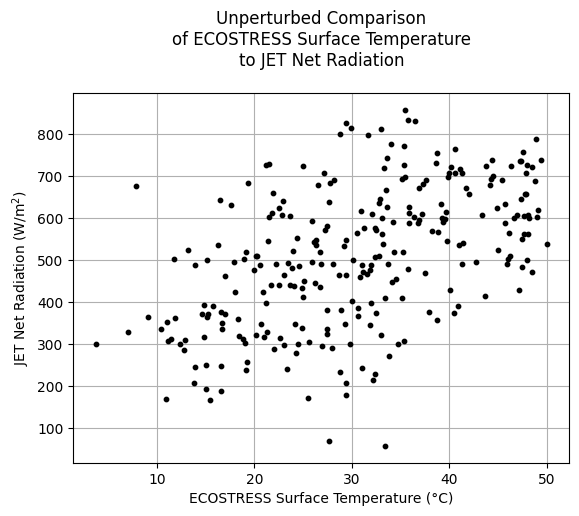

In [11]:
plt.scatter(x=processed.ST_C, y=processed.Rn_Wm2, color='black', s=10, zorder=5)
plt.grid(True, zorder=0)
plt.xlabel("ECOSTRESS Surface Temperature (°C)")
plt.ylabel(f"{model_name} Net Radiation (W/m$^2$)")
plt.title(f"Unperturbed Comparison\nof ECOSTRESS Surface Temperature\nto {model_name} Net Radiation", pad=20)

if SAVE_PLOTS:
    plt.savefig(f"Unperturbed Comparison of ECOSTRESS Surface Temperature to {model_name} Net Radiation.jpeg", format='jpeg', bbox_inches='tight')
    plt.savefig(f"Unperturbed Comparison of ECOSTRESS Surface Temperature to {model_name} Net Radiation.svg", format='svg', bbox_inches='tight')

plt.show()

## Plot Unperturbed Comparison of Surface Temperature to Evapotranspiration

This cell creates a scatter plot comparing ECOSTRESS surface temperature to BESS-JPL evapotranspiration for the unperturbed data. The plot is saved as both JPEG and SVG files for publication or further analysis.

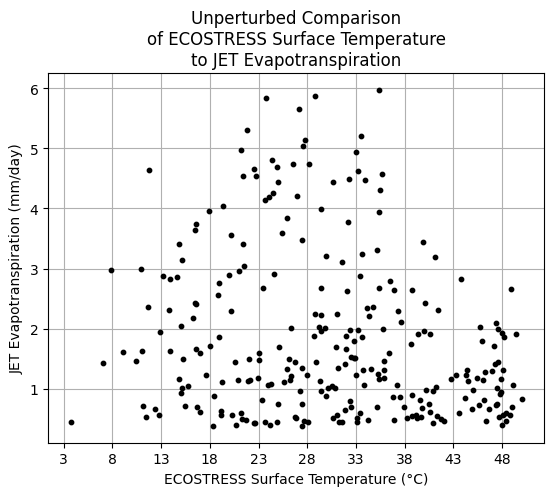

In [12]:
plt.xticks(range(int(min(processed.ST_C)), int(max(processed.ST_C)) + 1, 5))
plt.scatter(x=processed.ST_C, y=processed.ET_daylight_kg, color='black', s=10, zorder=5)
plt.grid(True, zorder=0)
plt.xlabel("ECOSTRESS Surface Temperature (°C)")
plt.ylabel(f"{model_name} Evapotranspiration (mm/day)")
plt.title(f"Unperturbed Comparison\nof ECOSTRESS Surface Temperature\nto {model_name} Evapotranspiration")

if SAVE_PLOTS:
    plt.savefig(f"Unperturbed Comparison of ECOSTRESS Surface Temperature to {model_name} Evapotranspiration.jpeg", format='jpeg', bbox_inches='tight')
    plt.savefig(f"Unperturbed Comparison of ECOSTRESS Surface Temperature to {model_name} Evapotranspiration.svg", format='svg', bbox_inches='tight')

plt.show()

## Check Number of Valid Input Rows

This cell displays the number of rows remaining in the input DataFrame after all filtering steps, confirming the size of the dataset used for analysis.

In [13]:
len(input_df)

270

## Perturbed Model Analysis for Net Radiation

In [14]:
input_variable = "ST_C"
output_variable = "Rn_Wm2"

Rn_results = perturbed_run(
    input_df=input_df, 
    input_variable=input_variable, 
    output_variable=output_variable, 
    forward_process=process_JET_table,
    normalization_function=normalization_function
)

Rn_results

[2026-08-06 13:00:52 INFO] Starting Monte Carlo perturbed run
[2026-08-06 13:00:52 INFO] calculating standard deviation of input variable: ST_C
[2026-08-06 13:00:52 INFO] input variable ST_C standard deviation: 10.766741663428046
[2026-08-06 13:00:52 INFO] starting forward process
[2026-08-06 13:00:52 INFO] starting JET table processing
[2026-08-06 13:00:52 INFO] started extracting geometry from JET input table
[2026-08-06 13:00:52 INFO] completed extracting geometry from JET input table (0.004 seconds)
[2026-08-06 13:00:52 INFO] started extracting time from JET input table
[2026-08-06 13:00:52 INFO] completed extracting time from JET input table (0.001 seconds)
[2026-08-06 13:00:52 INFO] running Forest Light Environmental Simulator
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[2026-08-06 13:00:53 INFO] completed processing FLiES-ANN in 0.17 seconds
[2026-08-06 13:00:53 INFO] variable PAR_albedo min: 0.007 mean: 0.055 max: 0.193 nan: 0.00% (nan)
[2026-08-06 13:00:53 INFO] variable NIR_albedo 

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-p

[2026-08-06 13:00:53 INFO] variable Rs min: 7.009 mean: 54.052 max: 500.000 nan: 0.00% (nan)
[2026-08-06 13:00:53 INFO] variable SFd min: 0.020 mean: 0.051 max: 0.077 nan: 0.00% (nan)
[2026-08-06 13:00:53 INFO] variable SFd2 min: 0.172 mean: 0.334 max: 0.983 nan: 0.00% (nan)
[2026-08-06 13:00:53 INFO] variable DL min: 8.245 mean: 11.401 max: 14.086 nan: 0.00% (nan)
[2026-08-06 13:00:53 INFO] variable Ra min: 416.618 mean: 888.643 max: 1240.699 nan: 0.00% (nan)
[2026-08-06 13:00:53 INFO] variable fStress min: 0.012 mean: 0.239 max: 0.975 nan: 0.00% (nan)
[2026-08-06 13:00:53 INFO] variable VCmax_C3_sunlit_μmolm2s1 min: 2.423 mean: 27.344 max: 141.877 nan: 0.00% (nan)
[2026-08-06 13:00:53 INFO] variable VCmax_C4_sunlit_μmolm2s1 min: 1.561 mean: 22.475 max: 141.877 nan: 0.00% (nan)
[2026-08-06 13:00:53 INFO] variable VCmax_C3_shaded_μmolm2s1 min: 0.097 mean: 23.447 max: 215.178 nan: 0.00% (nan)
[2026-08-06 13:00:53 INFO] variable VCmax_C4_shaded_μmolm2s1 min: 0.069 mean: 21.750 max: 215.1

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-p

[2026-08-06 13:00:53 INFO] starting input perturbation generation
[2026-08-06 13:00:53 INFO] input perturbation generation completed
[2026-08-06 13:00:53 INFO] generating control group
[2026-08-06 13:00:53 INFO] normalizing input perturbations
[2026-08-06 13:00:53 INFO] applying perturbations
[2026-08-06 13:00:53 INFO] starting forward process for perturbed input
[2026-08-06 13:00:53 INFO] starting JET table processing
[2026-08-06 13:00:53 INFO] started extracting geometry from JET input table
[2026-08-06 13:00:54 INFO] completed extracting geometry from JET input table (0.284 seconds)
[2026-08-06 13:00:54 INFO] started extracting time from JET input table
[2026-08-06 13:00:54 INFO] completed extracting time from JET input table (0.012 seconds)
[2026-08-06 13:00:54 INFO] running Forest Light Environmental Simulator


...

[2026-08-06 13:00:58 INFO] completed daylight ET upscaling (elapsed: 0.67 seconds)
[2026-08-06 13:00:58 INFO] PT-JPL-SM model run complete (elapsed: 0.71 seconds)
[2026-08-06 13:00:58 INFO] completed processing PT-JPL-SM in 0.71 seconds
[2026-08-06 13:00:58 INFO] variable LE_PTJPLSM_Wm2 min: 0.000 mean: 191.062 max: 841.989 nan: 0.00% (nan)
[2026-08-06 13:00:58 INFO] variable ET_daylight_PTJPLSM_kg min: 0.000 mean: 2.609 max: 9.945 nan: 0.00% (nan)
[2026-08-06 13:00:58 INFO] variable G_PTJPLSM min: 0.000 mean: 66.344 max: 200.931 nan: 0.00% (nan)
[2026-08-06 13:00:58 INFO] variable EF_PTJPLSM min: 0.000 mean: 0.418 max: 0.964 nan: 0.00% (nan)
[2026-08-06 13:00:58 INFO] variable LE_canopy_PTJPLSM_Wm2 min: 0.000 mean: 127.778 max: 624.517 nan: 0.00% (nan)
[2026-08-06 13:00:58 INFO] variable LE_canopy_fraction_PTJPLSM min: 0.024 mean: 0.747 max: 0.979 nan: 0.14% (nan)
[2026-08-06 13:00:58 INFO] variable LE_soil_PTJPLSM_Wm2 min: 0.000 mean: 55.821 max: 590.291 nan: 0.00% (nan)
[2026-08-06 

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a spe

[2026-08-06 13:00:59 INFO] completed daylight ET upscaling (PMJPL)
[2026-08-06 13:00:59 INFO] completed processing PM-JPL in 0.81 seconds
[2026-08-06 13:00:59 INFO] variable LE_PMJPL_Wm2 min: 0.000 mean: 94.139 max: 538.513 nan: 0.00% (nan)
[2026-08-06 13:00:59 INFO] variable ET_daylight_PMJPL_kg min: 0.000 mean: 1.320 max: 6.718 nan: 0.00% (nan)
[2026-08-06 13:00:59 INFO] variable G_PMJPL_Wm2 min: 0.000 mean: 66.344 max: 200.931 nan: 0.00% (nan)
[2026-08-06 13:00:59 INFO] variable ET_daylight_kg min: 0.000 mean: 1.734 max: 7.581 nan: 0.00% (nan)
[2026-08-06 13:00:59 INFO] JET table processing complete (6.373 seconds)
[2026-08-06 13:00:59 INFO] completed forward process for perturbed input
[2026-08-06 13:00:59 INFO] normalizing output perturbations
[2026-08-06 13:00:59 INFO] Monte Carlo run complete


/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)


,input_variable,output_variable,input_unperturbed,input_perturbation,input_perturbation_std,input_perturbed,output_unperturbed,output_perturbation,output_perturbation_std,output_perturbed
0,ST_C,Rn_Wm2,20.01,-4.188599,0.209325,15.821401,476.697616,22.772034,0.04777,499.469650
1,ST_C,Rn_Wm2,20.01,-12.100343,0.604715,7.909657,476.697616,63.164361,0.132504,539.861976
2,ST_C,Rn_Wm2,20.01,14.636782,0.731473,34.646782,476.697616,-87.595202,0.183754,389.102414
3,ST_C,Rn_Wm2,20.01,5.103628,0.255054,25.113628,476.697616,-29.097442,0.06104,447.600173
4,ST_C,Rn_Wm2,20.01,-6.883862,0.344021,13.126138,476.697616,36.911152,0.077431,513.608768
...,...,...,...,...,...,...,...,...,...,...
26995,ST_C,Rn_Wm2,35.23,7.013370,0.199074,42.24337,519.082396,-45.949445,0.088521,473.132951
26996,ST_C,Rn_Wm2,35.23,-12.924865,0.366871,22.305135,519.082396,76.841919,0.148034,595.924315
26997,ST_C,Rn_Wm2,35.23,-16.495116,0.468212,18.734884,519.082396,96.367401,0.18565,615.449797
26998,ST_C,Rn_Wm2,35.23,7.869377,0.223371,43.099377,519.082396,-51.771962,0.099737,467.310434


## Perturbed Model Analysis for Evapotranspiration

In [15]:
input_variable = "ST_C"
output_variable = "ET_daylight_kg"

ET_results = perturbed_run(
    input_df=input_df, 
    input_variable=input_variable, 
    output_variable=output_variable, 
    forward_process=forward_process,
    normalization_function=normalization_function
)

ET_results = ET_results.dropna()

ET_results

[2026-08-06 13:00:59 INFO] Starting Monte Carlo perturbed run
[2026-08-06 13:00:59 INFO] calculating standard deviation of input variable: ST_C
[2026-08-06 13:00:59 INFO] input variable ST_C standard deviation: 10.766741663428046
[2026-08-06 13:00:59 INFO] starting forward process
[2026-08-06 13:00:59 INFO] starting JET table processing
[2026-08-06 13:00:59 INFO] started extracting geometry from JET input table
[2026-08-06 13:00:59 INFO] completed extracting geometry from JET input table (0.004 seconds)
[2026-08-06 13:00:59 INFO] started extracting time from JET input table
[2026-08-06 13:00:59 INFO] completed extracting time from JET input table (0.001 seconds)
[2026-08-06 13:00:59 INFO] running Forest Light Environmental Simulator


/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[2026-08-06 13:01:00 INFO] completed processing FLiES-ANN in 0.17 seconds
[2026-08-06 13:01:00 INFO] variable PAR_albedo min: 0.007 mean: 0.055 max: 0.193 nan: 0.00% (nan)
[2026-08-06 13:01:00 INFO] variable NIR_albedo min: 0.066 mean: 0.162 max: 0.530 nan: 0.00% (nan)
[2026-08-06 13:01:00 INFO] variable PAR_direct_Wm2 min: 7.148 mean: 269.735 max: 442.463 nan: 0.00% (nan)
[2026-08-06 13:01:00 INFO] variable SWin_FLiES_ANN min: 163.676 mean: 716.916 max: 1095.605 nan: 0.00% (nan)
[2026-08-06 13:01:00 INFO] running Breathing Earth System Simulator
<class 'numpy.ndarray'>
float32
[2026-08-06 13:01:00 INFO] variable SZA_deg min: 17.642 mean: 46.017 max: 72.208 nan: 0.00% (nan)
[2026-08-06 13:01:00 INFO] variable CI min: 0.188 mean: 0.266 max: 0.298 nan: 0.00% (nan)
[2026-08-06 13:01:00 INFO] variable elevation_m min: 7.300 mean: 1164.656 max: 3504.000 nan: 0.00% (nan)
[2026-08-06 13:01:00 INFO] variable NDVI_minimum min: -0.017 mean: 0.172 max: 0.569 

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)


[2026-08-06 13:01:00 INFO] variable SFd min: 0.020 mean: 0.051 max: 0.077 nan: 0.00% (nan)
[2026-08-06 13:01:00 INFO] variable SFd2 min: 0.172 mean: 0.334 max: 0.983 nan: 0.00% (nan)
[2026-08-06 13:01:00 INFO] variable DL min: 8.245 mean: 11.401 max: 14.086 nan: 0.00% (nan)
[2026-08-06 13:01:00 INFO] variable Ra min: 416.618 mean: 888.643 max: 1240.699 nan: 0.00% (nan)
[2026-08-06 13:01:00 INFO] variable fStress min: 0.012 mean: 0.239 max: 0.975 nan: 0.00% (nan)
[2026-08-06 13:01:00 INFO] variable VCmax_C3_sunlit_μmolm2s1 min: 2.423 mean: 27.344 max: 141.877 nan: 0.00% (nan)
[2026-08-06 13:01:00 INFO] variable VCmax_C4_sunlit_μmolm2s1 min: 1.561 mean: 22.475 max: 141.877 nan: 0.00% (nan)
[2026-08-06 13:01:00 INFO] variable VCmax_C3_shaded_μmolm2s1 min: 0.097 mean: 23.447 max: 215.178 nan: 0.00% (nan)
[2026-08-06 13:01:00 INFO] variable VCmax_C4_shaded_μmolm2s1 min: 0.069 mean: 21.750 max: 215.178 nan: 0.00% (nan)
[2026-08-06 13:01:00 INFO] variable PARDiff min: 18.773 mean: 43.453 max:

...

[2026-08-06 13:01:06 INFO] completed daylight ET upscaling (elapsed: 0.68 seconds)
[2026-08-06 13:01:06 INFO] PT-JPL-SM model run complete (elapsed: 0.72 seconds)
[2026-08-06 13:01:06 INFO] completed processing PT-JPL-SM in 0.72 seconds
[2026-08-06 13:01:06 INFO] variable LE_PTJPLSM_Wm2 min: 0.000 mean: 190.621 max: 831.953 nan: 0.00% (nan)
[2026-08-06 13:01:06 INFO] variable ET_daylight_PTJPLSM_kg min: 0.000 mean: 2.604 max: 10.125 nan: 0.00% (nan)
[2026-08-06 13:01:06 INFO] variable G_PTJPLSM min: 0.000 mean: 66.538 max: 200.911 nan: 0.00% (nan)
[2026-08-06 13:01:06 INFO] variable EF_PTJPLSM min: 0.000 mean: 0.418 max: 0.964 nan: 0.00% (nan)
[2026-08-06 13:01:06 INFO] variable LE_canopy_PTJPLSM_Wm2 min: 0.000 mean: 127.605 max: 607.541 nan: 0.00% (nan)
[2026-08-06 13:01:06 INFO] variable LE_canopy_fraction_PTJPLSM min: 0.097 mean: 0.747 max: 0.979 nan: 0.14% (nan)
[2026-08-06 13:01:06 INFO] variable LE_soil_PTJPLSM_Wm2 min: 0.000 mean: 55.571 max: 542.169 nan: 0.00% (nan)
[2026-08-06

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a spe

[2026-08-06 13:01:06 INFO] completed daylight ET upscaling (PMJPL)
[2026-08-06 13:01:06 INFO] completed processing PM-JPL in 0.77 seconds
[2026-08-06 13:01:06 INFO] variable LE_PMJPL_Wm2 min: 0.000 mean: 94.074 max: 529.908 nan: 0.00% (nan)
[2026-08-06 13:01:06 INFO] variable ET_daylight_PMJPL_kg min: 0.000 mean: 1.319 max: 6.965 nan: 0.00% (nan)
[2026-08-06 13:01:06 INFO] variable G_PMJPL_Wm2 min: 0.000 mean: 66.538 max: 200.911 nan: 0.00% (nan)
[2026-08-06 13:01:06 INFO] variable ET_daylight_kg min: 0.000 mean: 1.733 max: 7.910 nan: 0.00% (nan)
[2026-08-06 13:01:06 INFO] JET table processing complete (6.399 seconds)
[2026-08-06 13:01:06 INFO] completed forward process for perturbed input
[2026-08-06 13:01:06 INFO] normalizing output perturbations
[2026-08-06 13:01:06 INFO] Monte Carlo run complete


/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)


,input_variable,output_variable,input_unperturbed,input_perturbation,input_perturbation_std,input_perturbed,output_unperturbed,output_perturbation,output_perturbation_std,output_perturbed
0,ST_C,ET_daylight_kg,20.01,7.307256,0.365180,27.317256,2.900053,-0.457815,0.157864,2.442238
1,ST_C,ET_daylight_kg,20.01,2.677771,0.133822,22.687771,2.900053,-0.21693,0.074802,2.683123
2,ST_C,ET_daylight_kg,20.01,-0.351565,0.017569,19.658435,2.900053,0.0088,0.003035,2.908853
3,ST_C,ET_daylight_kg,20.01,-2.503362,0.125106,17.506638,2.900053,0.062022,0.021387,2.962075
4,ST_C,ET_daylight_kg,20.01,-21.786434,1.088777,-1.776434,2.900053,0.406109,0.140035,3.306162
...,...,...,...,...,...,...,...,...,...,...
26995,ST_C,ET_daylight_kg,35.23,14.336967,0.406953,49.566967,1.243506,-0.69112,0.555783,0.552386
26996,ST_C,ET_daylight_kg,35.23,-8.133393,0.230866,27.096607,1.243506,0.881295,0.708718,2.124802
26997,ST_C,ET_daylight_kg,35.23,9.791385,0.277927,45.021385,1.243506,-0.57409,0.46167,0.669417
26998,ST_C,ET_daylight_kg,35.23,-3.645577,0.103479,31.584423,1.243506,0.270918,0.217866,1.514424


## Plot Change in Surface Temperature vs Net Radiation

This cell generates a scatter plot showing the relationship between changes in surface temperature and changes in BESS-JPL net radiation due to input perturbations. The plot is saved as JPEG and SVG files.

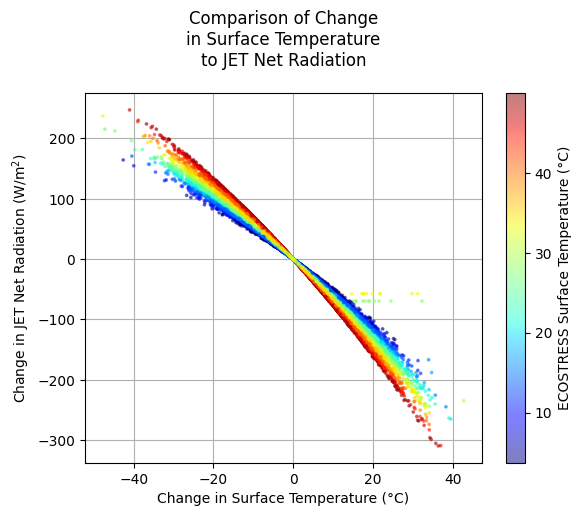

In [16]:
sc = plt.scatter(
    x=Rn_results.input_perturbation, 
    y=Rn_results.output_perturbation, 
    c=Rn_results.input_unperturbed, 
    color=None,
    cmap="jet",
    s=3,
    alpha=0.5, 
    zorder=5
)

plt.grid(True, zorder=0)
plt.xlabel("Change in Surface Temperature (°C)")
plt.ylabel(f"Change in {model_name} Net Radiation (W/m$^2$)")
plt.title(f"Comparison of Change\nin Surface Temperature\nto {model_name} Net Radiation", pad=20)
plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")

if SAVE_PLOTS:
    plt.savefig(f"Comparison of Change in Surface Temperature to {model_name} Net Radiation.jpeg", format='jpeg', bbox_inches='tight')
    plt.savefig(f"Comparison of Change in Surface Temperature to {model_name} Net Radiation.svg", format='svg', bbox_inches='tight')

plt.show()

## Plot Change in Surface Temperature vs Evapotranspiration

This cell generates a scatter plot showing the relationship between changes in surface temperature and changes in evapotranspiration due to input perturbations. The plot is saved as JPEG and SVG files.

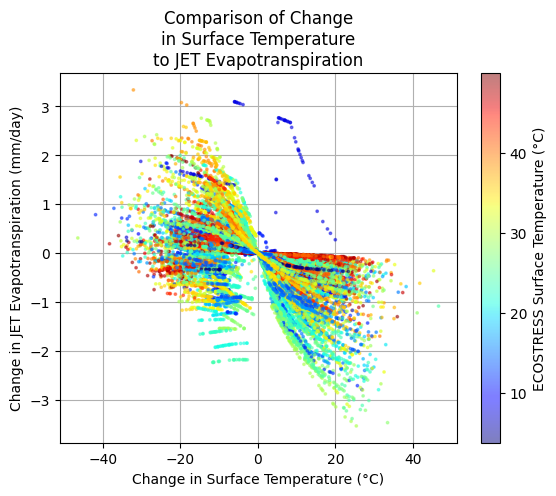

In [17]:
sc = plt.scatter(
    x=ET_results.input_perturbation, 
    y=ET_results.output_perturbation, 
    c=ET_results.input_unperturbed, 
    color=None,
    cmap="jet",
    s=3,
    alpha=0.5, 
    zorder=5
)

plt.grid(True, zorder=0)
plt.xlabel("Change in Surface Temperature (°C)")
plt.ylabel(f"Change in {model_name} Evapotranspiration (mm/day)")
plt.title(f"Comparison of Change\nin Surface Temperature\nto {model_name} Evapotranspiration")
plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")

if SAVE_PLOTS:
    plt.savefig(f"Comparison of Change in Surface Temperature to {model_name} Evapotranspiration.jpeg", format='jpeg', bbox_inches='tight')
    plt.savefig(f"Comparison of Change in Surface Temperature to {model_name} Evapotranspiration.svg", format='svg', bbox_inches='tight')

plt.show()

## Run Full Sensitivity Analysis for Multiple Inputs

This cell performs a comprehensive sensitivity analysis by perturbing several input variables (surface temperature, NDVI, albedo, air temperature, relative humidity) and measuring their effect on latent heat flux. The results are summarized in a DataFrame.

In [18]:
perturbation_df, sensitivity_metrics_df = sensitivity_analysis(
    input_df=input_df,
    input_variables=input_variables,
    output_variables=output_variables,
    forward_process=process_JET_table,
    normalization_function=normalization_function,
    use_joint_run=True,  # Explicitly enable joint run mode
    input_min=input_min,
    input_max=input_max
 )

sensitivity_metrics_df

[2026-08-06 13:01:07 INFO] starting JET table processing
[2026-08-06 13:01:07 INFO] started extracting geometry from JET input table
[2026-08-06 13:01:07 INFO] completed extracting geometry from JET input table (0.003 seconds)
[2026-08-06 13:01:07 INFO] started extracting time from JET input table
[2026-08-06 13:01:07 INFO] completed extracting time from JET input table (0.001 seconds)
[2026-08-06 13:01:07 INFO] running Forest Light Environmental Simulator
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[2026-08-06 13:01:07 INFO] completed processing FLiES-ANN in 0.17 seconds
[2026-08-06 13:01:07 INFO] variable PAR_albedo min: 0.007 mean: 0.055 max: 0.193 nan: 0.00% (nan)
[2026-08-06 13:01:07 INFO] variable NIR_albedo min: 0.066 mean: 0.162 max: 0.530 nan: 0.00% (nan)
[2026-08-06 13:01:07 INFO] variable PAR_direct_Wm2 min: 7.148 mean: 269.735 max: 442.463 nan: 0.00% (nan)
[2026-08-06 13:01:07 INFO] variable SWin_FLiES_ANN min: 163.676 mean: 716.916 max: 1095.605 nan: 0.00% (nan)
[2026-08-06 13:0

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-p

[2026-08-06 13:01:07 INFO] variable VCmax_C3_sunlit_μmolm2s1 min: 2.423 mean: 27.344 max: 141.877 nan: 0.00% (nan)
[2026-08-06 13:01:07 INFO] variable VCmax_C4_sunlit_μmolm2s1 min: 1.561 mean: 22.475 max: 141.877 nan: 0.00% (nan)
[2026-08-06 13:01:07 INFO] variable VCmax_C3_shaded_μmolm2s1 min: 0.097 mean: 23.447 max: 215.178 nan: 0.00% (nan)
[2026-08-06 13:01:07 INFO] variable VCmax_C4_shaded_μmolm2s1 min: 0.069 mean: 21.750 max: 215.178 nan: 0.00% (nan)
[2026-08-06 13:01:07 INFO] variable PARDiff min: 18.773 mean: 43.453 max: 194.457 nan: 0.00% (nan)
[2026-08-06 13:01:07 INFO] variable PARDir min: 7.148 mean: 269.735 max: 442.463 nan: 0.00% (nan)
[2026-08-06 13:01:07 INFO] variable NIRDiff min: 0.000 mean: 25.057 max: 346.098 nan: 0.00% (nan)
[2026-08-06 13:01:07 INFO] variable NIRDir min: 0.004 mean: 337.810 max: 559.698 nan: 0.00% (nan)
[2026-08-06 13:01:07 INFO] variable UV min: 12.171 mean: 42.068 max: 67.767 nan: 0.00% (nan)
[2026-08-06 13:01:07 INFO] variable SZA min: 17.642 me

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-p

[2026-08-06 13:01:08 INFO] starting JET table processing
[2026-08-06 13:01:11 INFO] started extracting geometry from JET input table
[2026-08-06 13:01:14 INFO] completed extracting geometry from JET input table (2.515 seconds)
[2026-08-06 13:01:14 INFO] started extracting time from JET input table
[2026-08-06 13:01:14 INFO] completed extracting time from JET input table (0.262 seconds)
[2026-08-06 13:01:14 INFO] running Forest Light Environmental Simulator


...

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-p

[2026-08-06 13:02:13 INFO] completed daylight ET upscaling (PMJPL)
[2026-08-06 13:02:13 INFO] completed processing PM-JPL in 7.90 seconds
[2026-08-06 13:02:13 INFO] variable LE_PMJPL_Wm2 min: 0.000 mean: 97.088 max: 780.303 nan: 1.43% (nan)
[2026-08-06 13:02:13 INFO] variable ET_daylight_PMJPL_kg min: 0.000 mean: 1.361 max: 9.001 nan: 1.43% (nan)
[2026-08-06 13:02:13 INFO] variable G_PMJPL_Wm2 min: 0.000 mean: 68.299 max: 208.295 nan: 1.43% (nan)
[2026-08-06 13:02:13 INFO] variable ET_daylight_kg min: 0.000 mean: 1.838 max: 9.316 nan: 0.00% (nan)


/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)


[2026-08-06 13:02:14 INFO] JET table processing complete (65.362 seconds)


,input_variable,output_variable,metric,value
0,ST_C,LE_BESS_Wm2,correlation,0.112308
1,ST_C,LE_BESS_Wm2,r2,0.012613
2,ST_C,LE_BESS_Wm2,mean_normalized_change,0.515657
3,NDVI,LE_BESS_Wm2,correlation,0.638555
4,NDVI,LE_BESS_Wm2,r2,0.407752
...,...,...,...,...
160,elevation_m,LE_Wm2,r2,0.007172
161,elevation_m,LE_Wm2,mean_normalized_change,0.029534
162,canopy_height_meters,LE_Wm2,correlation,0.104924
163,canopy_height_meters,LE_Wm2,r2,0.011009


## Plot Sensitivity Magnitude Bar Chart

This cell creates a bar chart showing the average percent change in latent heat flux for each input variable, visualizing the magnitude of model sensitivity to each input.

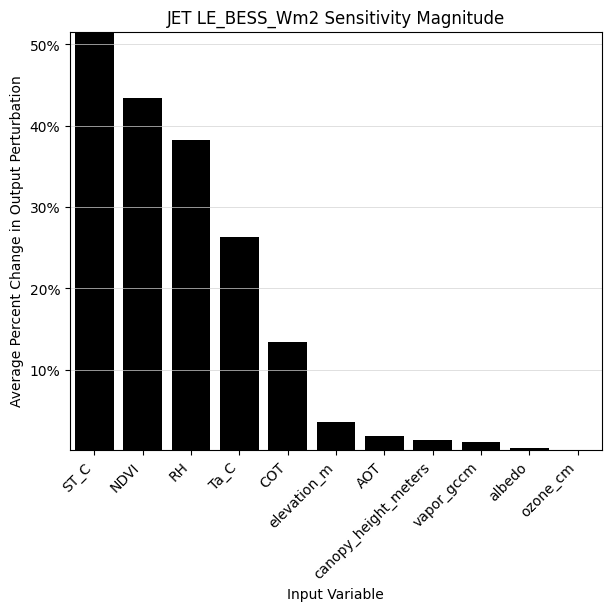

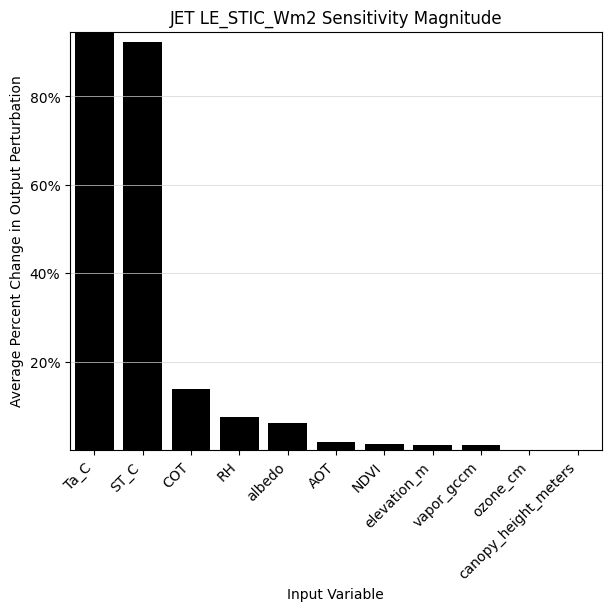

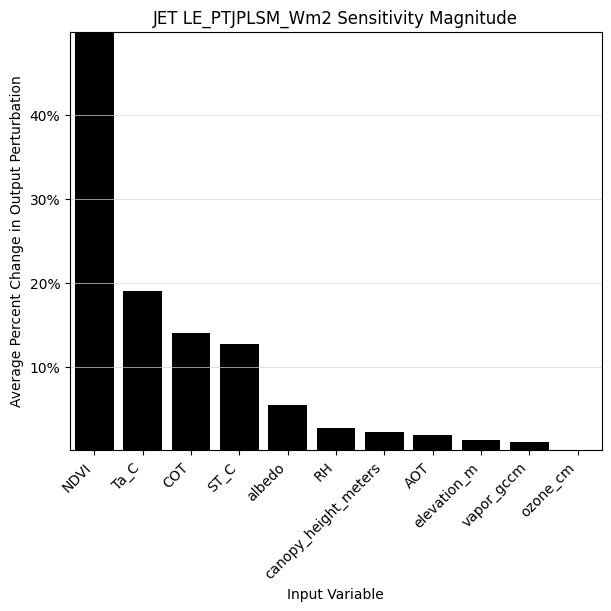

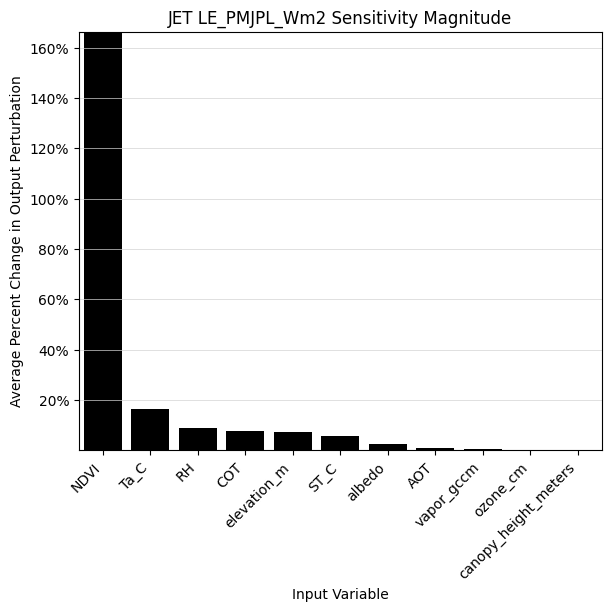

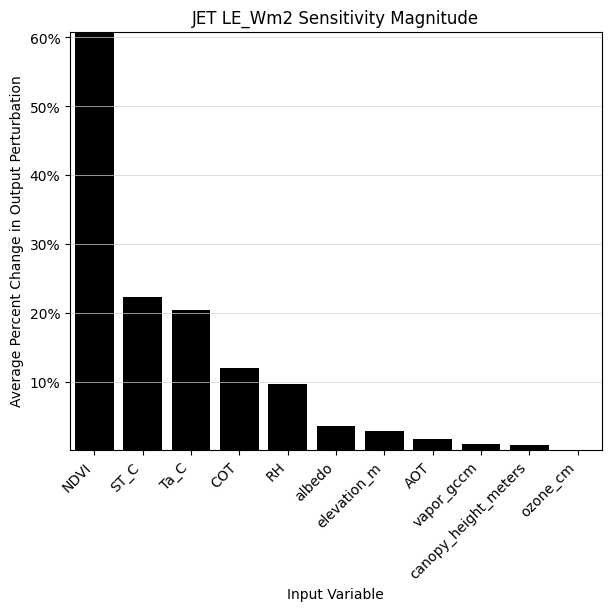

In [19]:
for output_variable in output_variables:
    sensitivity_magnitude_barchart(
        model_name=model_name,
        output_variable=output_variable,
        df=sensitivity_metrics_df
    )

## Summary and Next Steps

This notebook demonstrated a full sensitivity analysis workflow for the BESS-JPL model using ECOSTRESS Cal-Val data. Key results include the identification of input variables with the greatest influence on latent heat flux. Next steps could include further exploration of model parameters, additional visualizations, or application to other datasets.